<a href="https://colab.research.google.com/github/izia2081-0038-create/PlantVillage-Crop-Disease-Detection/blob/main/PlantVillage_crop_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q kagglehub

In [2]:
import os
import io
import json
import random
import warnings
import itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU") or "None (training will be slow)")

TensorFlow : 2.20.0
GPU        : None (training will be slow)


In [3]:
SEED = 42

QUICK_RUN     = False              # True -> ~250 imgs/class, 2 epochs. Use for a smoke test.
BACKBONE      = "resnet50"         # "resnet50" or "efficientnetb0"
RUN_ABLATION  = False              # §10. Adds ~10 min. Turn on for the final run.

IMG_SIZE      = (224, 224)         # standard input size for both backbones
BATCH_SIZE    = 32
TARGET_CROPS  = ("Corn_(maize)", "Potato", "Tomato")   # PlantVillage folder prefixes
SPLIT_RATIOS  = (0.70, 0.15, 0.15)                     # train / val / test

EPOCHS_CNN    = 20                 # baseline CNN from scratch
EPOCHS_HEAD   = 8                  # transfer learning, stage 1 (frozen backbone)
EPOCHS_FINE   = 10                 # transfer learning, stage 2 (fine-tuning)

if QUICK_RUN:
    EPOCHS_CNN, EPOCHS_HEAD, EPOCHS_FINE = 2, 2, 2

# --- Reproducibility -------------------------------------------------
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# --- Working directories (auto-detects Colab / Kaggle / local) --------
if Path("/kaggle/working").exists():
    WORK_DIR = Path("/kaggle/working")
elif Path("/content").exists():
    WORK_DIR = Path("/content")
else:
    WORK_DIR = Path.cwd() / "work"

MODEL_DIR   = WORK_DIR / "models"
RESULTS_DIR = WORK_DIR / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORK_DIR)
print("Models ->", MODEL_DIR)
print("Results ->", RESULTS_DIR)
print("Quick run   :", QUICK_RUN)
print("Backbone    :", BACKBONE)

Working dir : /content
Models -> /content/models
Results -> /content/results
Quick run   : False
Backbone    : resnet50


In [4]:
DATA_DIR = None

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

if DATA_DIR is None:
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists() and any(kaggle_input.iterdir()):
        DATA_DIR = kaggle_input
        print("Using Kaggle-mounted dataset at:", DATA_DIR)
    else:
        import kagglehub
        DATA_DIR = Path(kagglehub.dataset_download("mohitsingh1804/plantvillage"))
        print("Dataset downloaded to:", DATA_DIR)
else:
    DATA_DIR = Path(DATA_DIR)
    assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"
    print("Using local dataset at:", DATA_DIR)

100%|██████████| 818M/818M [00:09<00:00, 92.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1


In [5]:
def find_class_root(base, target_prefixes=TARGET_CROPS, max_depth=5):
    '''
    Return the directory whose immediate subfolders are the per-class image folders.

    Scoring: prefer the directory with the most subfolders matching our target crops;
    fall back to the directory with the most image-containing subfolders. This makes the
    notebook robust to the wrapper folders PlantVillage uploads often have
    (e.g. .../plantvillage/PlantVillage/Tomato___Late_blight/...).
    '''
    base = Path(base)
    best, best_score = None, (0, 0)

    for root, dirs, _ in os.walk(base):
        root = Path(root)
        if len(root.relative_to(base).parts) > max_depth:
            dirs[:] = []
            continue

        n_target, n_with_images = 0, 0
        for d in dirs:
            p = root / d
            try:
                has_img = any(f.suffix.lower() in IMG_EXTS
                              for f in itertools.islice(p.iterdir(), 25))
            except OSError:
                has_img = False
            if has_img:
                n_with_images += 1
                if d.startswith(target_prefixes):
                    n_target += 1

        score = (n_target, n_with_images)
        if score > best_score:
            best, best_score = root, score

    return best


CLASS_ROOT = find_class_root(DATA_DIR)
if CLASS_ROOT is None:
    raise FileNotFoundError(
        "Could not auto-detect the class-folder root. Inspect os.listdir(DATA_DIR) "
        "and set CLASS_ROOT manually to the folder that directly contains the "
        "'Tomato___...', 'Potato___...' subfolders."
    )

all_classes = sorted(d.name for d in CLASS_ROOT.iterdir() if d.is_dir())
print("Class root  :", CLASS_ROOT)
print(f"Found {len(all_classes)} class folders in total.")
print("Sample      :", all_classes[:3], "...")

Class root  : /root/.cache/kagglehub/datasets/mohitsingh1804/plantvillage/versions/1/PlantVillage/val
Found 38 class folders in total.
Sample      : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust'] ...


In [6]:

selected_classes = sorted(c for c in all_classes if c.startswith(TARGET_CROPS))
assert selected_classes, "No matching classes found — check CLASS_ROOT and folder names."

print(f"Keeping {len(selected_classes)} of {len(all_classes)} classes:\n")
for c in selected_classes:
    print("  -", c)

# --- Build one tidy DataFrame of every image -------------------------
records = []
for cls in selected_classes:
    for f in (CLASS_ROOT / cls).iterdir():
        if f.suffix.lower() in IMG_EXTS:
            records.append({"filepath": str(f), "label": cls})

df = pd.DataFrame(records)


def parse_label(label):
    # "Tomato___Early_blight" -> ("Tomato", "Early blight", False)
    crop, _, condition = label.partition("___")
    crop = crop.replace("_", " ").strip()
    condition = condition.replace("_", " ").strip() or "Unknown"
    return pd.Series([crop, condition, "healthy" in condition.lower()])


df[["crop", "condition", "is_healthy"]] = df["label"].apply(parse_label)

print(f"\nTotal images in scope : {len(df):,}")
print(f"Classes               : {df['label'].nunique()}")
print(f"Crops                 : {sorted(df['crop'].unique())}")
df.head()

Keeping 17 of 38 classes:

  - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  - Corn_(maize)___Common_rust_
  - Corn_(maize)___Northern_Leaf_Blight
  - Corn_(maize)___healthy
  - Potato___Early_blight
  - Potato___Late_blight
  - Potato___healthy
  - Tomato___Bacterial_spot
  - Tomato___Early_blight
  - Tomato___Late_blight
  - Tomato___Leaf_Mold
  - Tomato___Septoria_leaf_spot
  - Tomato___Spider_mites Two-spotted_spider_mite
  - Tomato___Target_Spot
  - Tomato___Tomato_Yellow_Leaf_Curl_Virus
  - Tomato___Tomato_mosaic_virus
  - Tomato___healthy

Total images in scope : 4,834
Classes               : 17
Crops                 : ['Corn (maize)', 'Potato', 'Tomato']


,filepath,label,crop,condition,is_healthy
0,/root/.cache/kagglehub/datasets/mohitsingh1804...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
1,/root/.cache/kagglehub/datasets/mohitsingh1804...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
2,/root/.cache/kagglehub/datasets/mohitsingh1804...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
3,/root/.cache/kagglehub/datasets/mohitsingh1804...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False
4,/root/.cache/kagglehub/datasets/mohitsingh1804...,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,Corn (maize),Cercospora leaf spot Gray leaf spot,False


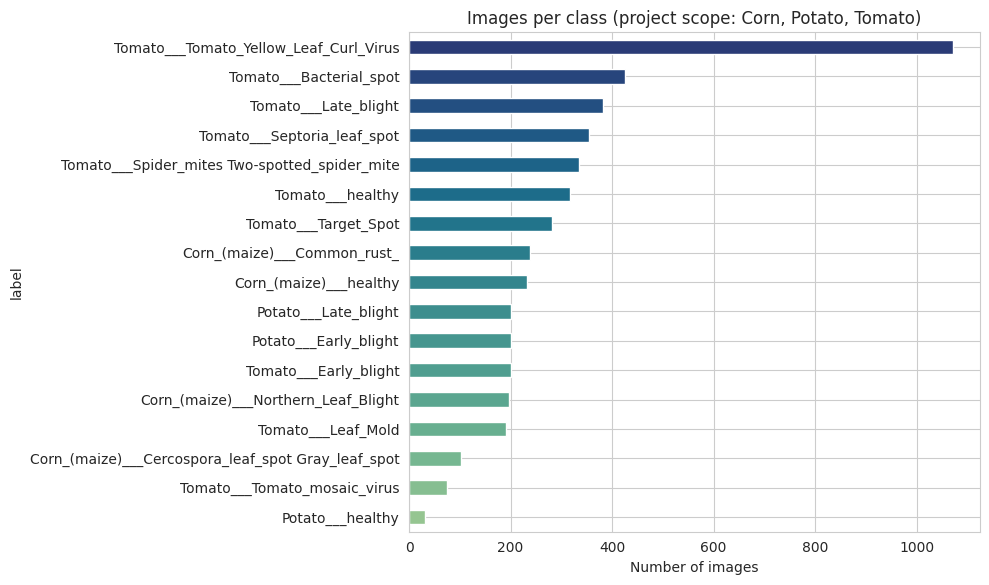

Smallest class : Potato___healthy -> 31
Largest class  : Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 1,071
Imbalance ratio: 34.5x

-> Imbalance is material, so class weights are applied during training (§5.3).


In [7]:
class_counts = df["label"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(class_counts))))
class_counts.plot(kind="barh", ax=ax,
                  color=sns.color_palette("crest", len(class_counts)))
ax.set_xlabel("Number of images")
ax.set_title("Images per class (project scope: Corn, Potato, Tomato)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_class_distribution.png", dpi=150)
plt.show()

imbalance = class_counts.max() / class_counts.min()
print(f"Smallest class : {class_counts.idxmin()} -> {class_counts.min():,}")
print(f"Largest class  : {class_counts.idxmax()} -> {class_counts.max():,}")
print(f"Imbalance ratio: {imbalance:.1f}x")
print("\n-> Imbalance is material, so class weights are applied during training (§5.3)."
      if imbalance > 3 else "\n-> Imbalance is mild.")

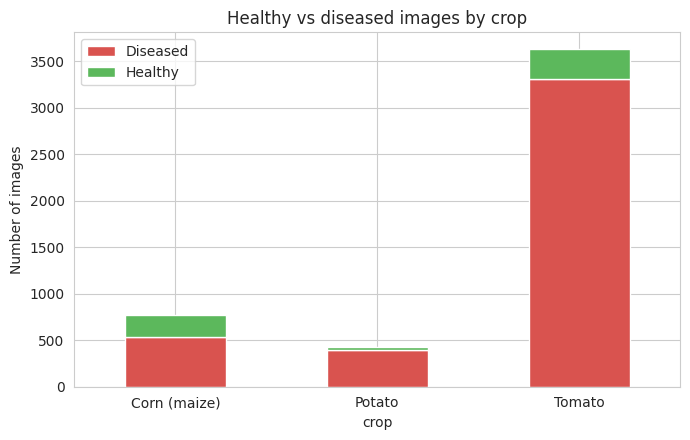

,Diseased,Healthy,% healthy
crop,,,
Corn (maize),539,233,30.2
Potato,400,31,7.2
Tomato,3313,318,8.8


In [8]:
health = df.pivot_table(index="crop", columns="is_healthy", aggfunc="size", fill_value=0)
health.columns = ["Diseased", "Healthy"]

ax = health.plot(kind="bar", stacked=True, figsize=(7, 4.5),
                 color=["#d9534f", "#5cb85c"])
ax.set_ylabel("Number of images")
ax.set_title("Healthy vs diseased images by crop")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eda_healthy_vs_diseased.png", dpi=150)
plt.show()

health["% healthy"] = (100 * health["Healthy"] / health.sum(axis=1)).round(1)
health

In [9]:
def find_corrupt(paths):
    bad = []
    for p in paths:
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            bad.append(p)
    return bad


corrupt = find_corrupt(df["filepath"])
print(f"Checked {len(df):,} images -> {len(corrupt)} unreadable.")

if corrupt:
    df = df[~df["filepath"].isin(corrupt)].reset_index(drop=True)
    print(f"Dropped them. {len(df):,} images remain.")

Checked 4,834 images -> 0 unreadable.


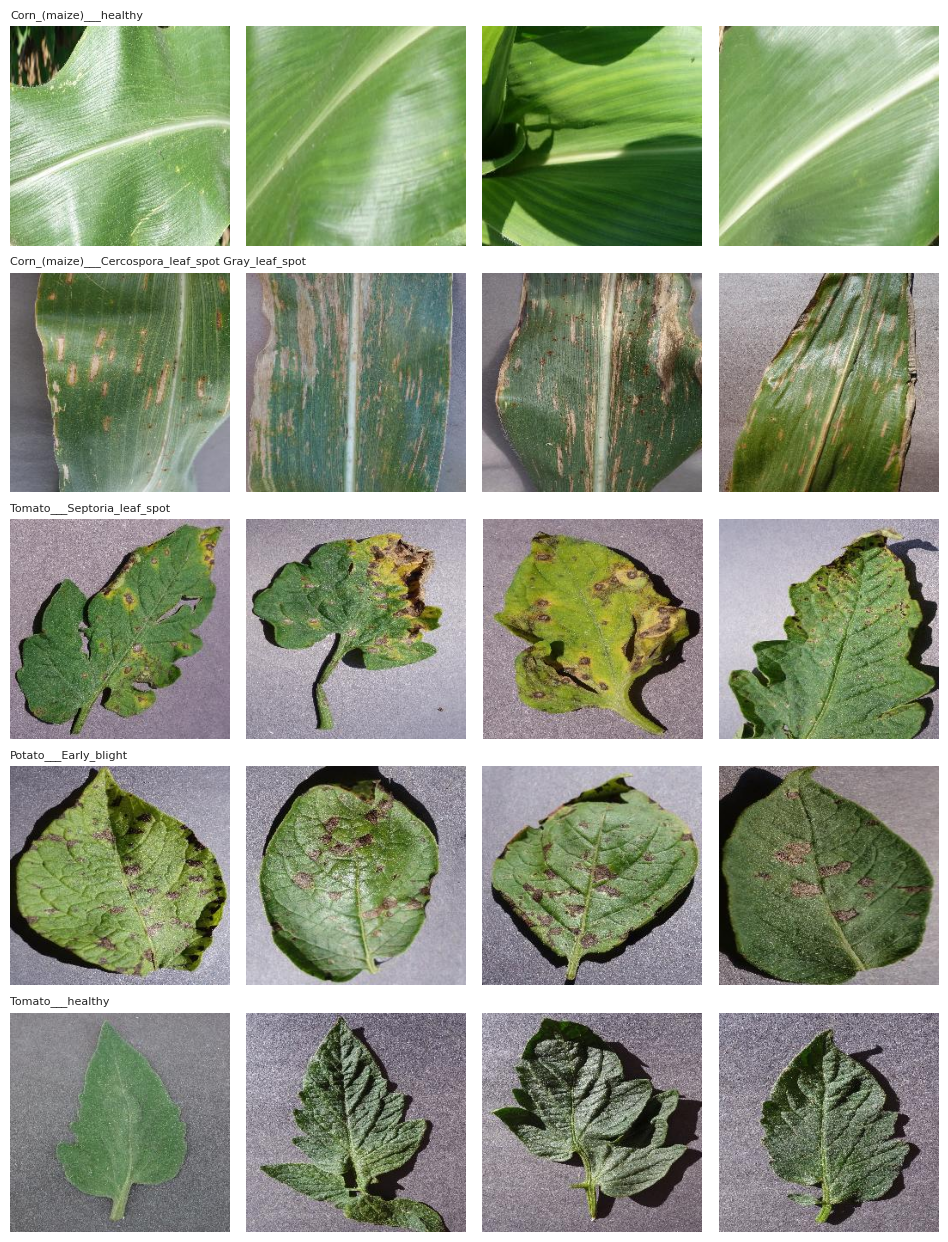

In [10]:
def show_sample_grid(dataframe, n_classes=5, n_per_class=4, seed=SEED):
    rng = random.Random(seed)
    labels = rng.sample(sorted(dataframe["label"].unique()),
                        min(n_classes, dataframe["label"].nunique()))

    fig, axes = plt.subplots(len(labels), n_per_class,
                             figsize=(n_per_class * 2.4, len(labels) * 2.5))
    axes = np.atleast_2d(axes)

    for r, label in enumerate(labels):
        paths = (dataframe[dataframe["label"] == label]["filepath"]
                 .sample(n=n_per_class, random_state=seed).tolist())
        for c, p in enumerate(paths):
            axes[r, c].imshow(Image.open(p))
            axes[r, c].axis("off")
        axes[r, 0].set_title(label, fontsize=8, loc="left")

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "eda_sample_images.png", dpi=130)
    plt.show()


show_sample_grid(df)

In [11]:
sample_paths = df["filepath"].sample(n=min(400, len(df)), random_state=SEED)
dims = []
for p in sample_paths:
    try:
        with Image.open(p) as im:
            dims.append(im.size)
    except Exception:
        continue          # belt-and-braces: §3.3 should already have removed these

dims_df = pd.DataFrame(dims, columns=["width", "height"])
print(dims_df.describe().loc[["min", "mean", "max"]].round(1))
print("\nMost common resolutions:")
print(dims_df.groupby(["width", "height"]).size().sort_values(ascending=False).head(3))
print(f"\n-> Resizing everything to {IMG_SIZE}, which both ResNet50 and "
      "EfficientNetB0 expect.")

      width  height
min   256.0   256.0
mean  256.0   256.0
max   256.0   256.0

Most common resolutions:
width  height
256    256       400
dtype: int64

-> Resizing everything to (224, 224), which both ResNet50 and EfficientNetB0 expect.
